In [7]:
!pip install -q mlflow optuna langchain-google-genai langgraph python-dotenv

In [8]:
import os
import mlflow
import optuna
import xgboost as xgb
import pandas as pd
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph
from typing import TypedDict
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
# Global Configurations
MODEL_VERSION = "v1.0"
MODEL_ACCURACY = 0.0
ACCURACY_THRESHOLD = 0.75
EXPERIMENT_NAME = "Diabetes_MLOps_Agent"
DATA_PATH = "diabetes_prediction_dataset.csv"

In [10]:
# Load Dataset
df = pd.read_csv(DATA_PATH)
df = pd.get_dummies(df, columns=['smoking_history', 'gender'])
X = df.drop(columns=["diabetes"])
y = df["diabetes"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
# Initialize MLflow
mlflow.set_experiment(EXPERIMENT_NAME)

<Experiment: artifact_location='/content/mlruns/1', creation_time=1785008919477, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785008919477, lifecycle_stage='active', name='Diabetes_MLOps_Agent', tags={}, trace_location=None, workspace='default'>

In [12]:
from google.colab import userdata

# Initialize Gemini for decision-making
load_dotenv()
gemini_api_key = userdata.get("GEMINI_API_KEY")
if not gemini_api_key:
    raise ValueError(
        "Set GEMINI_API_KEY (or GOOGLE_API_KEY) before running this notebook."
    )

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=gemini_api_key,
    temperature=0,
    max_retries=2,
    vertexai=False,
)

In [13]:
# Hyperparameter Optimization Function
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
    }
    candidate_model = xgb.XGBClassifier(
        **params, eval_metric="logloss", random_state=42, n_jobs=-1
    )
    candidate_model.fit(X_train, y_train)
    preds = candidate_model.predict(X_test)
    return accuracy_score(y_test, preds)


In [14]:
# Train Initial Model
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
best_params = study.best_params
model = xgb.XGBClassifier(
    **best_params, eval_metric="logloss", random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
MODEL_ACCURACY = accuracy_score(y_test, model.predict(X_test))

[I 2026-07-25 19:50:09,430] A new study created in memory with name: no-name-816b7ca5-f499-4423-8776-50417c833f75
[I 2026-07-25 19:50:10,255] Trial 0 finished with value: 0.9723 and parameters: {'max_depth': 4, 'learning_rate': 0.286999751908755, 'n_estimators': 84}. Best is trial 0 with value: 0.9723.
[I 2026-07-25 19:50:11,275] Trial 1 finished with value: 0.9721 and parameters: {'max_depth': 7, 'learning_rate': 0.0478264548503371, 'n_estimators': 94}. Best is trial 0 with value: 0.9723.
[I 2026-07-25 19:50:16,699] Trial 2 finished with value: 0.97165 and parameters: {'max_depth': 4, 'learning_rate': 0.25872930291444235, 'n_estimators': 222}. Best is trial 0 with value: 0.9723.
[I 2026-07-25 19:50:19,824] Trial 3 finished with value: 0.97245 and parameters: {'max_depth': 5, 'learning_rate': 0.10846654885245455, 'n_estimators': 98}. Best is trial 3 with value: 0.97245.
[I 2026-07-25 19:50:23,058] Trial 4 finished with value: 0.97215 and parameters: {'max_depth': 6, 'learning_rate': 0.

In [15]:
# Log Model to MLflow
with mlflow.start_run():
    mlflow.log_params(best_params)
    mlflow.log_metric("accuracy", MODEL_ACCURACY)
    mlflow.xgboost.log_model(model, "model")


2026/07/25 19:50:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [16]:
# MLOps Workflow Functions
def monitor_model(state):
    """Monitor model performance."""
    print(f"Monitoring Model: {MODEL_VERSION}, Accuracy: {MODEL_ACCURACY:.4f}")
    status = "drift_detected" if MODEL_ACCURACY < ACCURACY_THRESHOLD else "model_healthy"
    return {"status": status}

def decide_retraining(state):
    """Decide if retraining is needed using an LLM."""
    prompt = (
        "You are an MLOps decision agent. The monitored model has accuracy "
        f"{MODEL_ACCURACY:.4f}, below the required threshold of "
        f"{ACCURACY_THRESHOLD:.4f}. Should the model be retrained? "
        "Reply with exactly YES or NO."
    )
    response = llm.invoke(prompt)
    decision = response.content.strip().upper()
    return {"status": "retrain" if decision == "YES" else "done"}

def retrain_model(state):
    """Retrain model with updated dataset & hyperparameters."""
    global MODEL_ACCURACY, MODEL_VERSION, model
    study.optimize(objective, n_trials=5)
    best_params = study.best_params
    new_model = xgb.XGBClassifier(
        **best_params, eval_metric="logloss", random_state=42, n_jobs=-1
    )
    new_model.fit(X_train, y_train)
    MODEL_ACCURACY = accuracy_score(y_test, new_model.predict(X_test))
    model = new_model
    major, minor = map(int, MODEL_VERSION.removeprefix("v").split("."))
    MODEL_VERSION = f"v{major}.{minor + 1}"
    with mlflow.start_run():
        mlflow.log_params(best_params)
        mlflow.log_metric("new_accuracy", MODEL_ACCURACY)
        mlflow.xgboost.log_model(new_model, "model")
    return {"status": "deploy"}

def deploy_model(state):
    """Deploy the updated model."""
    print(f"Deploying Model {MODEL_VERSION} with Accuracy: {MODEL_ACCURACY:.4f}")
    return {"status": "done"}

def done(state):
    """End workflow."""
    print("MLOps Workflow Completed Successfully!")
    return state

In [17]:
# Define Workflow State Schema
class MLOpsState(TypedDict):
    status: str  # Workflow status (e.g., "monitoring", "retraining")

In [18]:
# Build Workflow with LangGraph
workflow = StateGraph(MLOpsState)
workflow.add_node("monitor", monitor_model)
workflow.add_node("decision", decide_retraining)
workflow.add_node("retrain", retrain_model)
workflow.add_node("deploy", deploy_model)
workflow.add_node("done", done)

workflow.set_entry_point("monitor")
workflow.add_conditional_edges("monitor", lambda state: "decision" if state["status"] == "drift_detected" else "done")
workflow.add_conditional_edges("decision", lambda state: "retrain" if state["status"] == "retrain" else "done")
workflow.add_edge("retrain", "deploy")
workflow.add_edge("deploy", "done")

In [19]:
# Compile and Run Workflow
agent = workflow.compile()
output = agent.invoke({"status": "monitoring"})
print("MLOps Workflow Output:", output)

Monitoring Model: v1.0, Accuracy: 0.9725
MLOps Workflow Completed Successfully!
MLOps Workflow Output: {'status': 'model_healthy'}


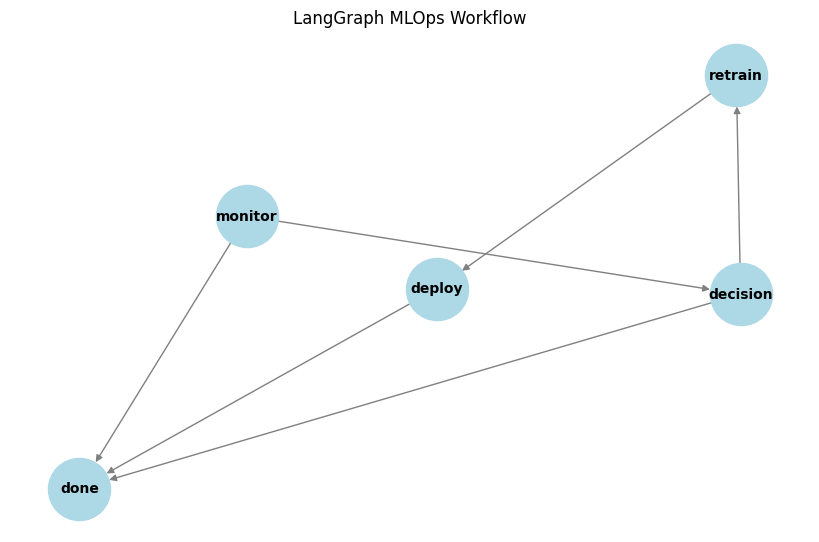

In [20]:
# Visualize Workflow
edges = [("monitor", "decision"), ("monitor", "done"), ("decision", "retrain"),
         ("decision", "done"), ("retrain", "deploy"), ("deploy", "done")]
G = nx.DiGraph()
G.add_edges_from(edges)
plt.figure(figsize=(8, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=10, font_weight="bold", arrows=True)
plt.title("LangGraph MLOps Workflow")
plt.show()
